# **Child Well-being - POSet creation**<br/>
**University: University of Milano-Bicocca**<br/>
**Master's Degree: Data Science (A.Y. 2025/2026)**<br/>
**Course: Data Science Lab**<br/>

---  
Use the Python Porting of R package `poseticDataAnalysis` by Avellone, De Capitani, Fattore.  
Added some implementations to work with Polars dataframes and handle `null` values ​​as uncertainty intervals in the hyperlattice.

**reference:**  
Fattore M., De Capitani L., Avellone A., Suardi A. (2024).  
*A fuzzy posetic toolbox for multi-criteria evaluation on ordinal data systems.*  
Annals of Operations Research. [doi:10.1007/s10479-024-06352-3](https://link.springer.com/article/10.1007/s10479-024-06352-3?utm_source=researchgate.net&utm_medium=article)

In [29]:
import sys; sys.path.insert(0, '..')
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import poset as P

---
## 0. Parameters summary -> `poset_from_polars`

| Parameter | Default | Description |
|-----------|---------|-------------|
| `col1` | `None` | First column to generate the ID |
| `col2` | `None` | Second column to generate the ID |
| `id_col` | `None` | Pre-existing ID (alternative to col1+col2) |
| `indicator_cols` | `None` | Indicator columns; if None -> all int |
| `higher_is_better` | `True` | High value = better position |
| `dominance_mode` | `'certain_or_possible'` | Type of dominance to calculate (certain, possible, certain_or_possible)  |
| `value_range` | `None` | Theoretical range `(min, max)` for null intervals |
| `max_null_frac` | `1.0` | Max null fraction to include a unit |
| `unit_sep` | `'_'` | ID separator |

**Dictionary key output returned:**
- `poset_certain` / `poset_possible` — the two POSets to use with all the library functions
- `intervals` — `{unit: {'lo': array, 'hi': array}}` — the region of each unit
- `confidence` — `{(a,b): float}` — reliability of each dominance pair
- `null_mask` — `{unit: bool array}` — where are the nulls

## 1. Import datasets

In [30]:
# Import dataset
ind_2018 = pl.read_parquet('../data/040_indicators_2018.parquet')
# select a subset of columns for example purposes
#ind_2018 = ind_2018.select(['REF_AREA', 'TIME_PERIOD', 'A1_2', 'A3_3', 'B2_5', 'C1_5'])
ind_2015 = pl.read_parquet('../data/040_indicators_2015.parquet')
# select a subset of columns for example purposes
#ind_2015 = ind_2015.select(['REF_AREA', 'TIME_PERIOD', 'A1_2', 'A3_3', 'B2_5', 'C1_5'])
exp_2018 = pl.read_parquet('../data/040_public_expenditure_2018.parquet') 
# select a subset of columns for example purposes
#exp_2018 = exp_2018.select(['REF_AREA', 'TIME_PERIOD', 'C2_1', 'C2_3', 'C4_4'])
exp_2015 = pl.read_parquet('../data/040_public_expenditure_2015.parquet')
# select a subset of columns for example purposes
#exp_2015 = exp_2015.select(['REF_AREA', 'TIME_PERIOD', 'C2_1', 'C2_3', 'C4_4'])
datasets = [ind_2018, ind_2015, exp_2018, exp_2015]
print('Data loaded successfully')

Data loaded successfully


---

## 2. Data extration and POSet creation

Since the `POSet(elements, dom)` constructor accepts `elements` as a list of labels and `dom` as a list of pairs `(a, b)` with `a ≤ b`, I need to extract the two lists from the datasets.  
The remaining `null` values are not missing data to be imputed; instead, they are treated as structural uncertainty: the unit does not occupy a single point in the hyperlattice, but rather a region, namely all points compatible with the observed values.  

The function uses the following normalization:
- every unit **a** with `null` on indicator **k** is compatible with any value along that dimension
- therefore, **a** represents an interval in the hyperlattice: `[a_lower, a_upper]`, where `a_lower` has the `null` values replaced with the minimum possible values and `a_upper` with the maximum
- Dominance then becomes interval dominance:
   - `a ≤ certain b` if `a_upper ≤ b_lower` (certainly below)
   - `a ≤ possible b` if `a_lower ≤ b_upper` (possibly below)
   - otherwise, they are incomparable


In [31]:
# Extract elemments and dominance from datasets
results = {}

for df in datasets:
    df_name = [k for k,v in globals().items() if v is df][0]
    print(f'Processing dataset [{df_name}]')
    result = P.poset_from_polars(
        df,
        col1='REF_AREA',      # area first element for ID
        col2='TIME_PERIOD',   # year second element for ID
        higher_is_better=True,
        dominance_mode='certain_or_possible',
    )
    results[df_name] = result

Processing dataset [ind_2018]
Processing dataset [ind_2015]
Processing dataset [exp_2018]
Processing dataset [exp_2015]


In [32]:
import pickle
import os

path = f"../data/050_posets.pkl"

with open(path, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

### 2.0 Selct the dataset to explore

In [33]:
result_sel = results['ind_2015'] # select the results for the dataset you want to explore

### 2.1 Ranges visualization

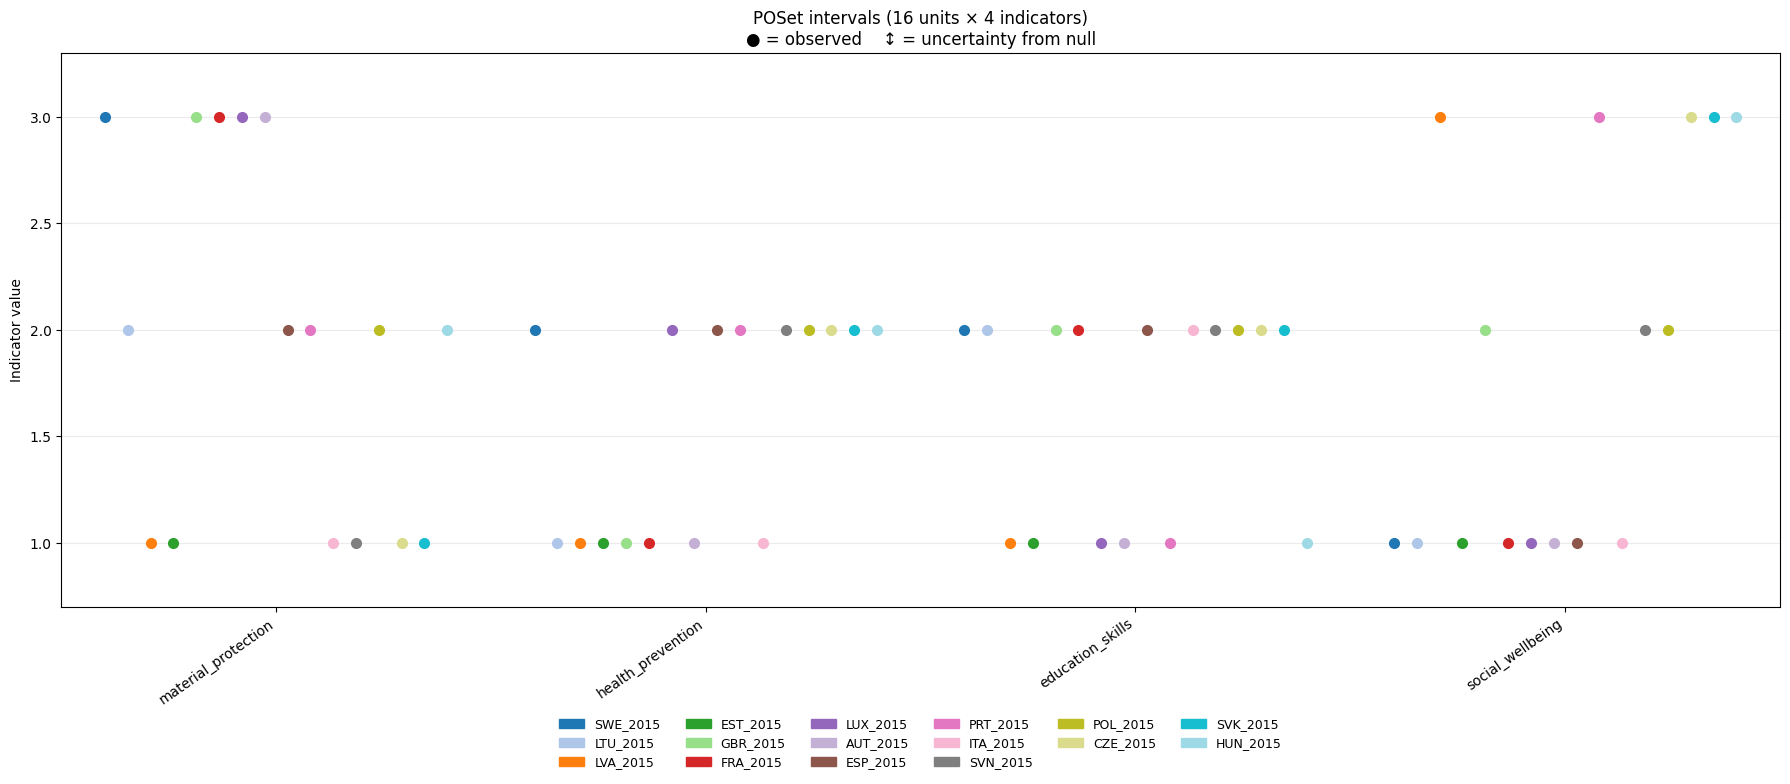

In [34]:
"""
Plot intervals for POSet elements.

Visualises observed values (points) and uncertainty intervals (bars)
for each statistical unit across all indicators in a POSet result.

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_poset_intervals(
    result: dict,
    figsize: tuple = (18, 9),
    marker_size: float = 7,
    bar_width: float = 3.5,
    bar_alpha: float = 0.55,
    max_units: int | None = None,
    title: str | None = None,
    ylabel: str = "Indicator value",
    xlabel_rotation: int = 35,
    legend_ncol: int = 6,
    cmap_name: str = "tab20",
    y_padding: float = 0.3,
    grid_alpha: float = 0.25,
    save_path: str | None = None,
    dpi: int = 150,
):
    """
    Plot uncertainty intervals for POSet elements.

    Parameters
    ----------
    result : dict
        Output of ``poset_from_polars()``.
    figsize : tuple
    marker_size : float
    bar_width : float
        Line width of uncertainty bars.
    bar_alpha : float
    max_units : int, optional
        Limit the number of displayed units (sorted alphabetically).
    title : str, optional
    ylabel, xlabel_rotation, legend_ncol : display options
    cmap_name : str
        Matplotlib colormap (default: 'tab20').
    y_padding : float
        Vertical padding around data range.
    save_path : str, optional
        If given, save figure to this path.
    dpi : int
    """
    # ----- Extract data from result dict -----
    units = result["elements"]
    intervals = result["intervals"]
    null_masks = result["null_mask"]
    sel_indicators = result["indicator_cols"]
    n_ind = len(sel_indicators)

    if max_units is not None and len(units) > max_units:
        units = sorted(units)[:max_units]

    n_units = len(units)

    # ----- Y-axis limits from data -----
    all_lo = np.array([intervals[u]["lo"] for u in units])
    all_hi = np.array([intervals[u]["hi"] for u in units])
    y_min = np.nanmin(all_lo) - y_padding
    y_max = np.nanmax(all_hi) + y_padding

    # ----- Adaptive spacing -----
    # Prevent overlap: total width per indicator tick should stay < 0.9
    spacing = min(0.12, 0.85 / max(n_units, 1))

    # ----- Color palette -----
    cmap = plt.colormaps.get_cmap(cmap_name).resampled(n_units)
    colors = [cmap(i) for i in range(n_units)]

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=figsize)

    for ui, unit in enumerate(units):
        lo = intervals[unit]["lo"]
        hi = intervals[unit]["hi"]
        nm = null_masks[unit]
        col = colors[ui]
        base_offset = (ui - n_units / 2 + 0.5) * spacing

        for j in range(n_ind):
            x = j + base_offset

            if not nm[j]:
                # Observed value → solid dot
                ax.plot(
                    x, lo[j], "o",
                    color=col, ms=marker_size, zorder=3,
                )
            else:
                # Null → uncertainty interval with end markers
                ax.plot(
                    [x, x], [lo[j], hi[j]], "-",
                    color=col, lw=bar_width,
                    alpha=bar_alpha, solid_capstyle="round",
                )
                ax.plot(x, lo[j], "v", color=col, ms=marker_size - 1, zorder=3)
                ax.plot(x, hi[j], "^", color=col, ms=marker_size - 1, zorder=3)

    # ----- Axes formatting -----
    ax.set_xticks(range(n_ind))
    ax.set_xticklabels(sel_indicators, rotation=xlabel_rotation, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(y_min, y_max)
    ax.grid(axis="y", alpha=grid_alpha)
    ax.set_xlim(-0.5, n_ind - 0.5)

    if title is None:
        title = (
            f"POSet intervals ({n_units} units × {n_ind} indicators)\n"
            "● = observed    ↕ = uncertainty from null"
        )
    ax.set_title(title, fontsize=12)

    # ----- Legend -----
    patches = [
        mpatches.Patch(color=colors[i], label=units[i])
        for i in range(n_units)
    ]
    ax.legend(
        handles=patches,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=min(legend_ncol, n_units),
        frameon=False,
        fontsize=9,
    )

    plt.subplots_adjust(bottom=0.28)
    plt.tight_layout(rect=[0, 0.12, 1, 1])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

    return fig, ax

fig, ax = plot_poset_intervals(result_sel)

# ----- Quick usage (paste in notebook cell) -----
# fig, ax = plot_poset_intervals(result_sel)
# fig, ax = plot_poset_intervals(result_sel, save_path="intervals.png")

### 2.2 Summary diagnostic
`interval_summary` returns the volume of the region of each unit:  
- for a country with no nulls it is 1 (point)  
- for a country with 3 nulls on range [1,5] it is 5^3 = 125 — a direct measure of how big its uncertainty zone is.

In [35]:
summary = P.interval_summary(result_sel)
pl.Config.set_tbl_rows(-1)       
pl.Config.set_tbl_cols(-1)        
display(summary)
print()
print('Interpretation interval_volume:')
print('  → volume = product of the widths of each dimension (indicator)')
print('  → volume = 1   if no null values (point)')
print('  → volume > 1   if there are null values (region in the hypercube)')

unit,n_null,null_frac,interval_volume,is_point,n_certain_dom,n_possible_dom,mean_confidence
str,i64,f64,f64,bool,i64,i64,f64
"""SWE_2015""",0,0.0,1.0,true,0,0,null
"""LTU_2015""",0,0.0,1.0,true,5,5,1.0
"""LVA_2015""",0,0.0,1.0,true,4,4,1.0
"""EST_2015""",0,0.0,1.0,true,15,15,1.0
"""GBR_2015""",0,0.0,1.0,true,0,0,null
"""FRA_2015""",0,0.0,1.0,true,2,2,1.0
"""LUX_2015""",0,0.0,1.0,true,1,1,1.0
"""AUT_2015""",0,0.0,1.0,true,4,4,1.0
"""ESP_2015""",0,0.0,1.0,true,2,2,1.0



Interpretation interval_volume:
  → volume = product of the widths of each dimension (indicator)
  → volume = 1   if no null values (point)
  → volume > 1   if there are null values (region in the hypercube)


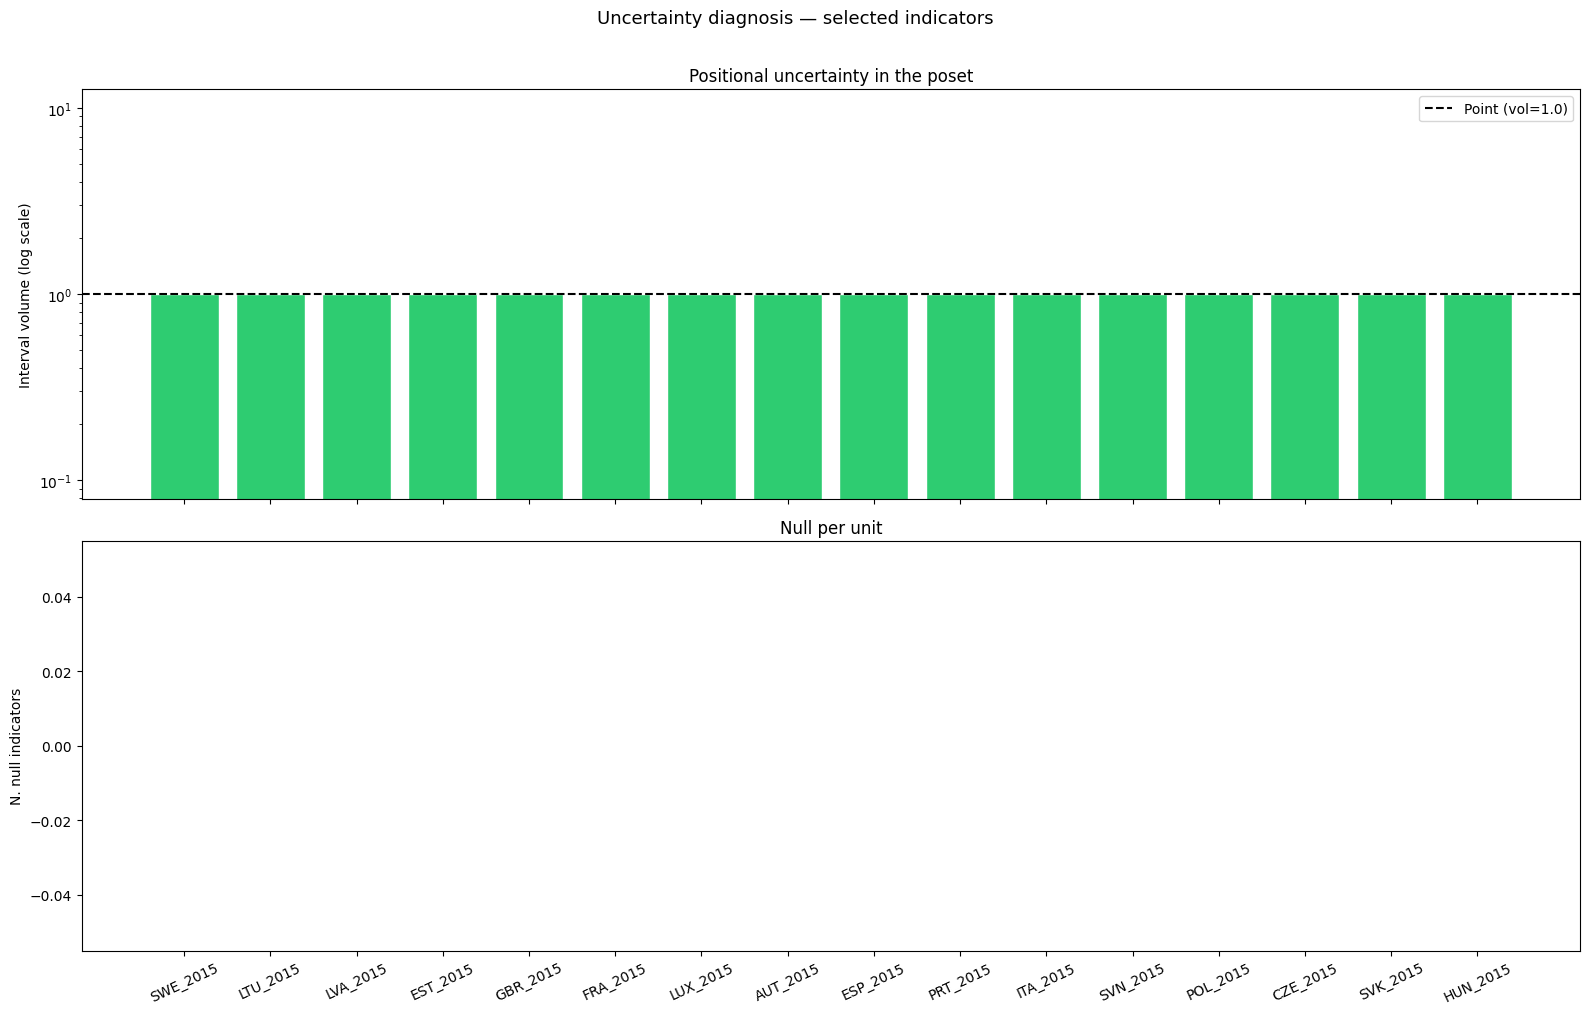

(<Figure size 1600x1000 with 2 Axes>,
 (<Axes: title={'center': 'Positional uncertainty in the poset'}, ylabel='Interval volume (log scale)'>,
  <Axes: title={'center': 'Null per unit'}, ylabel='N. null indicators'>))

In [36]:
def plot_uncertainty_diagnosis(
    summary: "pl.DataFrame",
    figsize: tuple = (16, 10),
    point_volume: float = 1.0,
    save_path: str | None = None,
    dpi: int = 150,
):
    """
    Two-panel diagnostic: interval volume and null count per unit.

    Parameters
    ----------
    summary : pl.DataFrame
        Output of ``interval_summary(result)``.
    """
    units_s = summary["unit"].to_list()
    volumes = summary["interval_volume"].to_list()
    n_nulls = summary["n_null"].to_list()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)

    # --- Panel 1: Interval volume ---
    bar_colors = [
        "#e74c3c" if v > point_volume else "#2ecc71" for v in volumes
    ]
    ax1.bar(units_s, volumes, color=bar_colors, edgecolor="white")
    ax1.axhline(
        point_volume, color="black", lw=1.5, ls="--", label=f"Point (vol={point_volume})"
    )
    ax1.set_ylabel("Interval volume (log scale)")
    ax1.set_yscale("log")
    ax1.set_title("Positional uncertainty in the poset")
    ax1.legend()

    # --- Panel 2: Null count ---
    ax2.bar(units_s, n_nulls, color="#3498db", edgecolor="white")
    ax2.set_ylabel("N. null indicators")
    ax2.set_title("Null per unit")
    ax2.tick_params(axis="x", rotation=25)

    fig.suptitle("Uncertainty diagnosis — selected indicators", fontsize=13, y=1.01)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()
    return fig, (ax1, ax2)

plot_uncertainty_diagnosis(summary)

## 3. POSet comparison - certain vs. possible

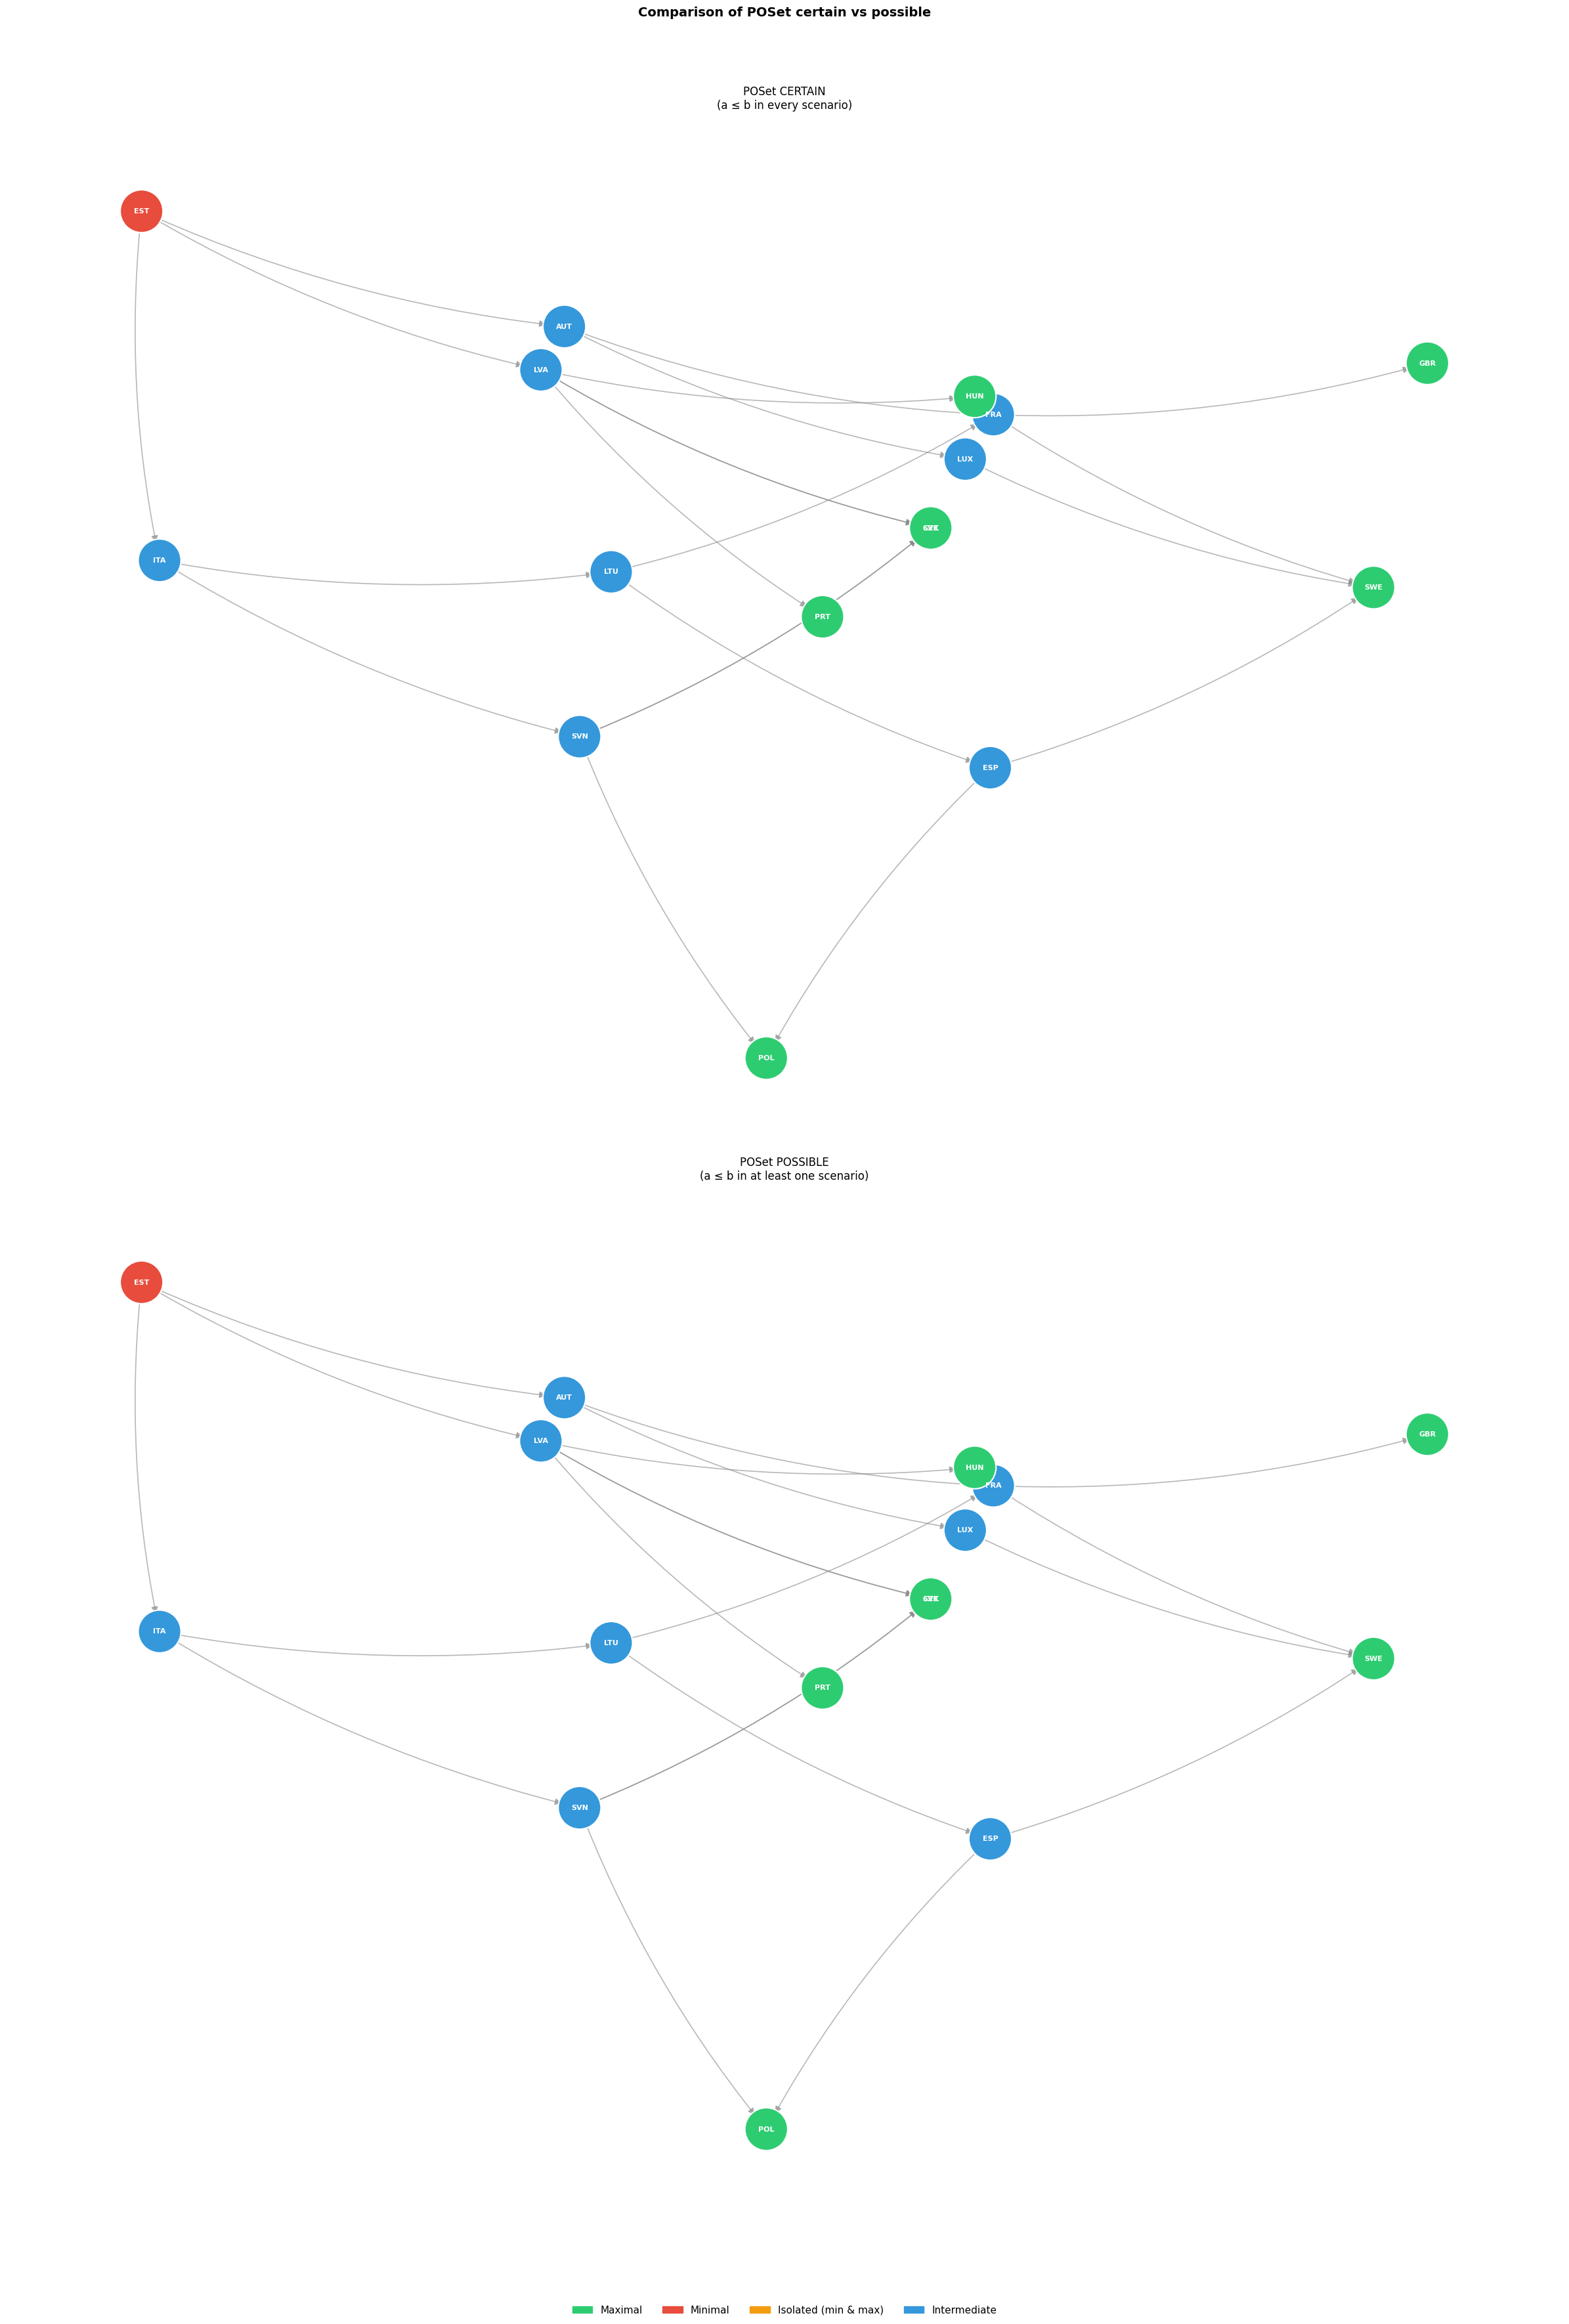

In [37]:
def plot_hasse(
    poset,
    title: str,
    ax,
    node_size: int = 2200,
    font_size: int = 8,
    arrow_size: int = 15,
    color_max: str = "#2ecc71",
    color_min: str = "#e74c3c",
    color_iso: str = "#f39c12",
    color_mid: str = "#3498db",
    layout_prog: str = "dot",
    rankdir: str = "BT",
):
    """
    Draw the Hasse diagram of a POSet.

    Parameters
    ----------
    poset : POSet
    title : str
    ax : matplotlib Axes
    rankdir : str
        'BT' = bottom-to-top (standard Hasse), 'LR' = left-to-right.
    """
    covers = P.CoverRelation(poset)
    G = nx.DiGraph()
    G.add_nodes_from(poset.elements)
    G.add_edges_from(covers)

    # Layout
    try:
        layout = nx.nx_agraph.graphviz_layout(
            G, prog=layout_prog,
            args=f'-Grankdir={rankdir} -Gnodesep=0.8 -Granksep=1.2'
        )
    except Exception:
        layout = nx.kamada_kawai_layout(G)

    minimals = set(P.POSetMinimals(poset))
    maximals = set(P.POSetMaximals(poset))

    colors = []
    for n in poset.elements:
        is_min = n in minimals
        is_max = n in maximals
        if is_min and is_max:
            colors.append(color_iso)
        elif is_max:
            colors.append(color_max)
        elif is_min:
            colors.append(color_min)
        else:
            colors.append(color_mid)

    # Shorten labels for display: "SWE_2015" → "SWE"
    label_map = {}
    for e in poset.elements:
        parts = e.split("_")
        label_map[e] = parts[0] if len(parts) > 1 else e

    # Draw edges first (below nodes)
    nx.draw_networkx_edges(
        G, layout, ax=ax,
        edge_color="#888",
        arrows=True,
        arrowsize=arrow_size,
        arrowstyle="-|>",
        connectionstyle="arc3,rad=0.08",
        width=1.2,
        alpha=0.6,
        min_source_margin=20,
        min_target_margin=20,
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, layout, ax=ax,
        node_color=colors,
        node_size=node_size,
        edgecolors="white",
        linewidths=1.5,
    )

    # Draw labels
    nx.draw_networkx_labels(
        G, layout, ax=ax,
        labels=label_map,
        font_color="white",
        font_size=font_size,
        font_weight="bold",
    )

    ax.set_title(title, fontsize=12, pad=15)
    ax.axis("off")


fig, axes = plt.subplots(2, 1, figsize=(24, 36))

plot_hasse(
    result_sel["poset_certain"],
    "POSet CERTAIN\n(a ≤ b in every scenario)",
    axes[0],
)
plot_hasse(
    result_sel["poset_possible"],
    "POSet POSSIBLE\n(a ≤ b in at least one scenario)",
    axes[1],
)

patches = [
    mpatches.Patch(color="#2ecc71", label="Maximal"),
    mpatches.Patch(color="#e74c3c", label="Minimal"),
    mpatches.Patch(color="#f39c12", label="Isolated (min & max)"),
    mpatches.Patch(color="#3498db", label="Intermediate"),
]
fig.legend(
    handles=patches, loc="lower center",
    ncol=4, fontsize=11, frameon=False,
)
fig.suptitle(
    "Comparison of POSet certain vs possible",
    fontsize=14, fontweight="bold", y=0.98,
)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

### 3.1 Confidence as a measure of dominance reliability

In [38]:
print('Intervals:')
for uid in result_sel['elements']:
    lo = result_sel['intervals'][uid]['lo']
    hi = result_sel['intervals'][uid]['hi']
    nm = result_sel['null_mask'][uid]
    inds = result_sel['indicator_cols']
    print(f'  {uid}:', end=' ')
    for j, ind in enumerate(inds):
        if nm[j]:
            print(f'{ind}=[{lo[j]:.0f},{hi[j]:.0f}]', end=' ')
        else:
            print(f'{ind}={lo[j]:.0f}', end=' ')
    print()

Intervals:
  SWE_2015: material_protection=3 health_prevention=2 education_skills=2 social_wellbeing=1 
  LTU_2015: material_protection=2 health_prevention=1 education_skills=2 social_wellbeing=1 
  LVA_2015: material_protection=1 health_prevention=1 education_skills=1 social_wellbeing=3 
  EST_2015: material_protection=1 health_prevention=1 education_skills=1 social_wellbeing=1 
  GBR_2015: material_protection=3 health_prevention=1 education_skills=2 social_wellbeing=2 
  FRA_2015: material_protection=3 health_prevention=1 education_skills=2 social_wellbeing=1 
  LUX_2015: material_protection=3 health_prevention=2 education_skills=1 social_wellbeing=1 
  AUT_2015: material_protection=3 health_prevention=1 education_skills=1 social_wellbeing=1 
  ESP_2015: material_protection=2 health_prevention=2 education_skills=2 social_wellbeing=1 
  PRT_2015: material_protection=2 health_prevention=2 education_skills=1 social_wellbeing=3 
  ITA_2015: material_protection=1 health_prevention=1 educa

In [39]:
print('Certain dominance:', result_sel['dom_certain'])
print('Possible dominance:', result_sel['dom_possible'])
print()
print('Confidence (indicators with no null on either unit):')
for pair, c in sorted(result_sel['confidence'].items()):
    kind = 'CERTAIN' if pair in set(result_sel['dom_certain']) else 'Only Possible'
    print(f'  {pair[0]} ≤ {pair[1]}  →  {c:.0%}  [{kind}]')

Certain dominance: [('LTU_2015', 'SWE_2015'), ('LTU_2015', 'GBR_2015'), ('LTU_2015', 'FRA_2015'), ('LTU_2015', 'ESP_2015'), ('LTU_2015', 'POL_2015'), ('LVA_2015', 'PRT_2015'), ('LVA_2015', 'CZE_2015'), ('LVA_2015', 'SVK_2015'), ('LVA_2015', 'HUN_2015'), ('EST_2015', 'SWE_2015'), ('EST_2015', 'LTU_2015'), ('EST_2015', 'LVA_2015'), ('EST_2015', 'GBR_2015'), ('EST_2015', 'FRA_2015'), ('EST_2015', 'LUX_2015'), ('EST_2015', 'AUT_2015'), ('EST_2015', 'ESP_2015'), ('EST_2015', 'PRT_2015'), ('EST_2015', 'ITA_2015'), ('EST_2015', 'SVN_2015'), ('EST_2015', 'POL_2015'), ('EST_2015', 'CZE_2015'), ('EST_2015', 'SVK_2015'), ('EST_2015', 'HUN_2015'), ('FRA_2015', 'SWE_2015'), ('FRA_2015', 'GBR_2015'), ('LUX_2015', 'SWE_2015'), ('AUT_2015', 'SWE_2015'), ('AUT_2015', 'GBR_2015'), ('AUT_2015', 'FRA_2015'), ('AUT_2015', 'LUX_2015'), ('ESP_2015', 'SWE_2015'), ('ESP_2015', 'POL_2015'), ('PRT_2015', 'HUN_2015'), ('ITA_2015', 'SWE_2015'), ('ITA_2015', 'LTU_2015'), ('ITA_2015', 'GBR_2015'), ('ITA_2015', 'FRA_